# E(2) Equivariant Diffusion: Un Exemple Jouet en 2D

Ce notebook implémente l'expérience 2D proposée dans le rapport. L'objectif est de démontrer visuellement *pourquoi* l'équivariance E(n) est essentielle pour apprendre des distributions de données géométriques, comme indiqué dans le papier EDM.

**Hypothèse :**
1.  **Modèle 1 (GDM - Non-équivariant)** : Un MLP standard qui reçoit des coordonnées "aplaties" (`(B, N*2)`) échouera. Il fera la moyenne de toutes les rotations et produira un "anneau" de bruit flou.
2.  **Modèle 2 (E(2)-DM - Équivariant)** : Un EGNN qui implémente les principes d'équivariance du papier (en utilisant les distances relatives $d_{ij}$ et les vecteurs $\vec{x}_i - \vec{x}_j$) réussira. Il apprendra la *forme* abstraite de la constellation et la générera à n'importe quelle rotation.

In [99]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [100]:
def get_canonical_permutation(sample, device='cpu'):
    """
    Calcule la permutation optimale des indices pour qu'un échantillon
    corresponde à l'ordre canonique de la 'Flèche' (basé sur la géométrie).
    
    Args:
        sample: Tensor (N, 2) - L'échantillon à analyser (idéalement à t=0).
    Returns:
        perm: List[int] - La liste des indices permutés.
    """
    # 1. Définition du Template (Flèche canonique)
    x_true = torch.tensor([
        [0.0, 0.0], [1.0, 0.0], [2.0, 0.0], [3.0, 0.0], [4.0, 0.0], # Queue -> Pointe
        [3.0, 1.0], [3.0, -1.0]                                     # Ailes
    ], dtype=torch.float32, device=device)
    x_true -= torch.mean(x_true, dim=0, keepdim=True)
    
    # 2. Calcul des Signatures (Distances internes triées)
    # Template
    d_temp = torch.cdist(x_true, x_true)
    sig_temp, _ = torch.sort(d_temp, dim=1)
    sig_temp = sig_temp.cpu().numpy()
    
    # Sample (Conversion CPU pour scipy)
    d_sample = torch.cdist(sample, sample)
    sig_sample, _ = torch.sort(d_sample, dim=1)
    sig_sample = sig_sample.detach().cpu().numpy()
    
    # 3. Matrice de Coût (Distance L2 entre les signatures)
    # cost[i, j] = distance entre le noeud i du sample et le noeud j du template
    cost_matrix = np.linalg.norm(
        sig_sample[:, None, :] - sig_temp[None, :, :], 
        axis=2
    )
    
    # 4. Matching Hongroisµ
    # row_ind = indices du sample, col_ind = indices du template correspondant
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # 5. Inversion du mapping pour obtenir la permutation
    # On veut perm tel que : sample[perm[k]] <-> template[k]
    # Donc si template[col] matche sample[row], alors perm[col] = row
    perm = np.zeros(sample.shape[0], dtype=int)
    perm[col_ind] = row_ind
    
    return perm.tolist()

def reorder_sample(sample, perm):
    """
    Applique une permutation donnée à un échantillon ou une trajectoire.
    
    Args:
        sample: Tensor (..., N, 2)
        perm: List[int] ou Array
    Returns:
        Tensor réordonné.
    """
    # Si perm est une liste, on peut indexer directement
    return sample[..., perm, :]

## 1. Création du Dataset 2D

Nous définissons une seule "constellation" de 5 points (une "maison") comme notre donnée de base. Le dataset d'entraînement sera composé de 10 000 copies de cette maison, chacune avec une rotation 2D et une translation aléatoires (la translation est annulée par la normalisation du centre de gravité, comme dans le papier).

Dataset shape: torch.Size([10000, 7, 2])


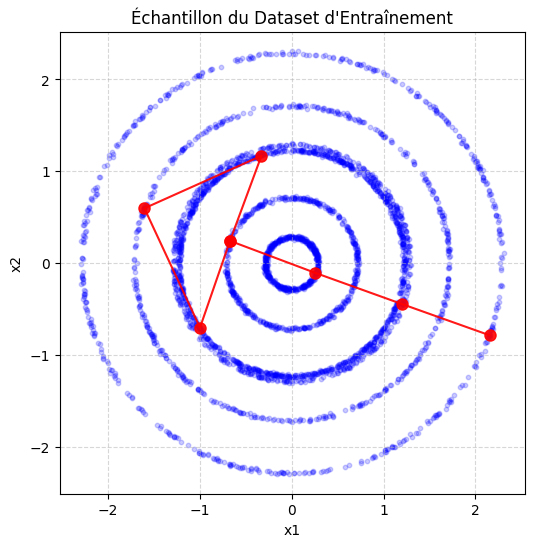

In [131]:
N = 7 # Nombre de "atomes" 2D

# 1. Définir la forme de la "Flèche"
x_true = torch.tensor([
    [0.0, 0.0],  # Queue
    [1.0, 0.0],  # Milieu 1
    [2.0, 0.0],  # Milieu 2
    [3.0, 0.0],  # Base de la tête
    [4.0, 0.0],  # Pointe
    [3.0, 1.0],  # Tête (haut)
    [3.0, -1.0]  # Tête (bas)
], dtype=torch.float32)

# 2. Centrer la forme
x_true -= torch.mean(x_true, dim=0, keepdim=True)

def create_dataset(num_samples, shape_true):
    dataset = torch.zeros(num_samples, N, 2)
    for i in range(num_samples):
        # Appliquer une rotation 2D aléatoire
        theta = torch.rand(1) * 2 * np.pi
        cos_t, sin_t = torch.cos(theta), torch.sin(theta)
        rot_matrix = torch.tensor([
            [cos_t, -sin_t],
            [sin_t,  cos_t]
        ]).squeeze()
        
        rotated_shape = shape_true @ rot_matrix.T
        dataset[i] = rotated_shape[torch.randperm(N), :] # random point order
    
    # Ajouter un tout petit peu de bruit pour éviter les zéros parfaits
    dataset += torch.randn_like(dataset) * 0.01
    return dataset.to(device)

dataset = create_dataset(10000, x_true)
print(f"Dataset shape: {dataset.shape}")

# Fonction de tracé (helper)
def plot_samples(samples, title, ax=None):
    if samples is None: return
    samples_cpu = samples.cpu().detach().numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    # Aplatir tous les échantillons pour le scatter plot
    ax.scatter(samples_cpu[:, :, 0].ravel(), 
               samples_cpu[:, :, 1].ravel(), 
               alpha=0.2, s=10, color='blue')
    
    # Tracer un échantillon en grand
    one_sample = samples_cpu[0]
    idxs = np.argsort(np.linalg.norm(one_sample, axis=1))
    idxs = idxs[[1, 2, 5, 3, 1, 0, 4, 6]]
    ax.plot(one_sample[idxs, 0], one_sample[idxs, 1], 'o-', color='red', markersize=8, alpha=0.9)
    
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

plot_samples(dataset[:500], "Échantillon du Dataset d'Entraînement")
plt.show()

## 2. Modèle de Diffusion (Base)

Nous définissons une classe de base `BaseDiffusion` qui gère le planning de bruit (`alpha`, `omega`), le `training_step`, et le `sample`. Les deux modèles (GDM et E(2)-DM) hériteront de cette classe, en ne surchargeant que `__init__` et `forward`.

In [102]:
class BaseDiffusion(nn.Module):
    def __init__(self, T=1000):
        super().__init__()
        self.T = T
        s = 1e-5
        
        # --- MODIFICATION : Schedule de Bruit Stabilisée ---
        
        # 1. Calculer la schedule "analytique" (instable)
        alpha_unstable = [(1-2*s)*(1 - (t/self.T)**2)+s for t in range(self.T+1)]
        alpha_unstable = torch.tensor(alpha_unstable, device=device, dtype=torch.float32)
        
        # 2. Calculer alpha_{t|t-1} = alpha_t / alpha_{t-1}
        # On ajoute alpha_{-1} = 1.0 au début pour le calcul
        alpha_unstable_padded = torch.cat([torch.tensor([1.0], device=device), alpha_unstable[:-1]])
        alpha_ts_unstable = alpha_unstable / alpha_unstable_padded
        
        # 3. Clipper alpha_{t|t-1}^2 comme dans le papier [cite: 481]
        alpha_ts_sq_clipped = torch.clamp(alpha_ts_unstable**2, min=0.001)
        alpha_ts_stable = torch.sqrt(alpha_ts_sq_clipped)
        
        # 4. Recalculer la schedule alpha stable en utilisant le produit cumulé [cite: 483]
        self.alpha = torch.cumprod(alpha_ts_stable, dim=0)
        
        # 5. Définir omega à partir de la schedule alpha stable
        self.omega = (1.0 - self.alpha**2).clamp(min=1e-8) # Clamp pour la stabilité du sqrt
        self.sqrt_omega = torch.sqrt(self.omega)
        
        # (Pour le training_step, ces alias sont OK)
        self.alpha_t = self.alpha
        self.omega_t = self.omega
        self.sqrt_omega_t = self.sqrt_omega
        
        print("Schedule de bruit stable initialisée.")
        
    def forward(self, x, t):
        # Doit être implémenté par les sous-classes
        raise NotImplementedError

    def training_step(self, x, optimizer):
        self.train()
        optimizer.zero_grad()

        B = x.shape[0]
        
        # t, eps_x, et centrage
        t_int = torch.randint(1, self.T + 1, (B, 1), device=device)
        eps_x = torch.randn_like(x, device=device)
        eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True) # Centre le bruit

        # Diffusion step: x_t = alpha_t * x + omega_t * eps_x
        alpha_val = self.alpha_t[t_int].view(B, 1, 1)
        omega_val = self.sqrt_omega_t[t_int].view(B, 1, 1)
        x_t = alpha_val * x + omega_val * eps_x
        
        # Prédire le bruit
        eps_x_pred = self.forward(x_t, t_int.float())

        # Perte L2
        loss = torch.nn.functional.mse_loss(eps_x_pred, eps_x)
        
        loss.backward()
        optimizer.step()

        return {'loss': loss.detach().cpu().item()}

    @torch.no_grad()
    def sample(self, batch_size, N):
        self.eval()
        # Sampler z_T ~ N(0, I)
        x = torch.randn(batch_size, N, 2, device=device)
        x = x - torch.mean(x, dim=1, keepdim=True) # Doit être dans le sous-espace

        # Boucle de t=T à 1
        for t in reversed(range(1, self.T + 1)):
            t_tensor = torch.full((batch_size, 1), t, device=device).float()
            dx = self.forward(x, t_tensor)

            # Équations de sampling (simplifiées de l'Algorithme 2)
            t_idx = t
            s_idx = t - 1
            
            alpha_t = self.alpha[t_idx]
            omega_t = self.omega[t_idx]
            alpha_s = self.alpha[s_idx]
            omega_s = self.omega[s_idx]

            alpha_ts = alpha_t/alpha_s
            omega_ts = omega_t - alpha_ts**2 * omega_s
            omega_t_s_sq = (omega_ts * omega_s) / omega_t
            omega_t_s = torch.sqrt(max(omega_t_s_sq, 1e-8))
            
            # Étape de reverse diffusion
            eps_x = 0.0
            if t > 1:
                eps_x = torch.randn_like(x)
                eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True)

            # Formule de x_{t-1}
            term1 = x / alpha_ts
            term2 = (omega_ts / (alpha_ts * torch.sqrt(omega_t))) * dx
            term3 = omega_t_s * eps_x
            x = term1 - term2 + term3
            
        return x

## 3. Modèle 1 : GDM (MLP Non-Équivariant)

Ce modèle "aplatit" les coordonnées d'entrée `(B, N, 2)` en `(B, N*2)`. Cet acte de `view()` ou `flatten()` **détruit** l'information de symétrie de rotation. Le modèle ne voit plus N points dans un espace 2D ; il voit un vecteur plat de 10 nombres.

In [103]:
class GDM_MLP(BaseDiffusion):
    def __init__(self, N, T=1000, nf_hidden=128):
        super().__init__(T)
        self.N = N
        self.nf_in = N * 2 # 5 * 2 = 10
        
        nf_time = 32
        self.time_mlp = nn.Sequential(
            nn.Linear(1, nf_time),
            nn.SiLU(),
            nn.Linear(nf_time, nf_time)
        )
        
        # Un simple MLP
        self.layers = nn.Sequential(
            nn.Linear(self.nf_in + nf_time, nf_hidden),
            nn.SiLU(),
            nn.Linear(nf_hidden, nf_hidden),
            nn.SiLU(),
            nn.Linear(nf_hidden, self.nf_in) # Sortie : bruit applati
        )

    def forward(self, x, t):
        B = x.shape[0]
        
        # --- L'ÉTAPE NON-ÉQUIVARIANTE --- 
        x_flat = x.view(B, -1)
        
        t_embed = self.time_mlp(t / self.T)
        h = torch.cat([x_flat, t_embed], dim=-1)
        
        eps_flat_pred = self.layers(h)
        
        # Reformater à la bonne taille de sortie
        return eps_flat_pred.view(B, self.N, 2)

## 4. Modèle 2 : E(2)-DM (EGNN Équivariant)

Ce modèle implémente les principes de l'EGNN du papier en 2D. Il n'aplatit jamais les coordonnées. Il n'utilise que des opérations E(2)-invariantes (distances $d_{ij}$) et E(2)-équivariantes (vecteurs $\vec{x}_i - \vec{x}_j$).

In [104]:
class E2DM_EGNN(BaseDiffusion):
    def __init__(self, N, T=1000, L=4, nf=64):
        super().__init__(T)
        self.N = N
        self.nf = nf
        self.L = L
        self.init_weight()

    def init_weight(self):
        self.phi_e = nn.ModuleList()
        self.phi_x = nn.ModuleList()
        self.phi_h = nn.ModuleList()

        # La seule feature d'entrée est le temps 't'
        nf_in = 1 
        self.h_embed = nn.Linear(nf_in, self.nf)

        for _ in range(self.L):
            # phi_e : [h_i, h_j, d_ij^2] -> m_ij
            self.phi_e.append(nn.Sequential(
                nn.Linear(self.nf * 2 + 1, self.nf),
                nn.SiLU(),
                nn.Linear(self.nf, self.nf)
            ))

            # phi_x : [h_i, h_j, d_ij^2] -> scalar weight
            self.phi_x.append(nn.Sequential(
                nn.Linear(self.nf * 2 + 1, self.nf),
                nn.SiLU(),
                nn.Linear(self.nf, 1)
            ))

            # phi_h : [h_i, m_agg] -> h_i_new
            self.phi_h.append(nn.Sequential(
                nn.Linear(self.nf + self.nf, self.nf),
                nn.SiLU(),
                nn.Linear(self.nf, self.nf)
            ))

    def forward(self, x, t):
        B = x.shape[0]
        x0 = x.clone() # Sauvegarder l'entrée z_t

        # h est juste l'embedding du temps
        t_embed = (t / self.T).expand(B, self.N).unsqueeze(-1)
        h = self.h_embed(t_embed) # (B, N, nf)

        for l in range(self.L):
            # --- OPÉRATIONS ÉQUIVARIANTES --- 
            
            # 1. Vecteurs de différence (Équivariant)
            diff = x.unsqueeze(2) - x.unsqueeze(1) # (B, N, N, 2)
            
            # 2. Distances au carré (Invariant)
            d_ij_sq = (diff ** 2).sum(dim=-1, keepdim=True).clamp(min=1e-9) # (B, N, N, 1)

            # 3. Préparer les features pour la diffusion (broadcasting)
            h_i = h.unsqueeze(2).expand(-1, -1, self.N, -1) # (B, N, N, nf)
            h_j = h.unsqueeze(1).expand(-1, self.N, -1, -1) # (B, N, N, nf)
            
            # [h_i, h_j, d_ij^2] -> (B, N, N, nf*2 + 1)
            features = torch.cat([h_i, h_j, d_ij_sq], dim=-1)

            # 4. Calculer les messages (phi_e) et les poids des coordonnées (phi_x)
            m_ij = self.phi_e[l](features) # (B, N, N, nf)
            phi_x_w = self.phi_x[l](features) # (B, N, N, 1)

            # 5. Mettre à jour les coordonnées (Équivariant)
            # x_i_new = x_i + sum_j( (x_i - x_j) * w )
            update_vec = diff * phi_x_w / (torch.sqrt(d_ij_sq) + 1.0)
            x = x + update_vec.sum(dim=2) # Somme sur j
            
            # 6. Mettre à jour les features (Invariant)
            mask = ~torch.eye(self.N, dtype=bool, device=device).unsqueeze(0).unsqueeze(-1)
            m_agg = (m_ij * mask).sum(dim=2) # (B, N, nf)
            
            h_new = self.phi_h[l](torch.cat([h, m_agg], dim=-1))
            h = h + h_new # Connexion résiduelle

        # Objectif de prédiction
        eps_x_pred = x - x0
        # Projeter à nouveau sur le sous-espace à centre de gravité nul
        eps_x_pred = eps_x_pred - torch.mean(eps_x_pred, dim=1, keepdim=True)
        
        return eps_x_pred

## 5. Entraînement et Comparaison des Résultats

In [105]:
# Initialiser les modèles
gdm_model = GDM_MLP(N=N).to(device)
e2dm_model = E2DM_EGNN(N=N, L=3, nf=32).to(device)

print("e2dm param count :", sum([np.prod(p.size()) for p in e2dm_model.parameters()]))
print("gdm param count :", sum([np.prod(p.size()) for p in gdm_model.parameters()]))

Schedule de bruit stable initialisée.
Schedule de bruit stable initialisée.
e2dm param count : 25411
gdm param count : 25454


In [106]:
# Paramètres d'entraînement
MAX_ITER = 20001
BATCH_SIZE = 128
LR = 1e-3

optim_gdm = optim.Adam(gdm_model.parameters(), lr=LR)
optim_e2dm = optim.Adam(e2dm_model.parameters(), lr=LR)

print("Démarrage de l'entraînement...")
for i in range(MAX_ITER):
    # Échantillonner un batch d'entraînement
    idx = torch.randint(0, len(dataset), (BATCH_SIZE,))
    batch = dataset[idx]
    
    # Entraîner les deux modèles sur le MÊME batch
    logs_gdm = gdm_model.training_step(batch, optim_gdm)
    logs_e2dm = e2dm_model.training_step(batch, optim_e2dm)
    
    if i % 1000 == 0:
        print(f"--- Iteration {i} ---")
        print(f"  GDM (MLP) Loss:   {logs_gdm['loss']:.6f}")
        print(f"  E2DM (EGNN) Loss: {logs_e2dm['loss']:.6f}")

print("Entraînement terminé.")

Démarrage de l'entraînement...
--- Iteration 0 ---
  GDM (MLP) Loss:   0.854498
  E2DM (EGNN) Loss: 3.207063
--- Iteration 1000 ---
  GDM (MLP) Loss:   0.433777
  E2DM (EGNN) Loss: 0.350715
--- Iteration 2000 ---
  GDM (MLP) Loss:   0.460060
  E2DM (EGNN) Loss: 0.317048
--- Iteration 3000 ---
  GDM (MLP) Loss:   0.448301
  E2DM (EGNN) Loss: 0.316555
--- Iteration 4000 ---
  GDM (MLP) Loss:   0.473707
  E2DM (EGNN) Loss: 0.299019
--- Iteration 5000 ---
  GDM (MLP) Loss:   0.476008
  E2DM (EGNN) Loss: 0.288690
--- Iteration 6000 ---
  GDM (MLP) Loss:   0.408624
  E2DM (EGNN) Loss: 0.241817
--- Iteration 7000 ---
  GDM (MLP) Loss:   0.405973
  E2DM (EGNN) Loss: 0.258548
--- Iteration 8000 ---
  GDM (MLP) Loss:   0.470630
  E2DM (EGNN) Loss: 0.296244
--- Iteration 9000 ---
  GDM (MLP) Loss:   0.462676
  E2DM (EGNN) Loss: 0.336804
--- Iteration 10000 ---
  GDM (MLP) Loss:   0.454317
  E2DM (EGNN) Loss: 0.325303
--- Iteration 11000 ---
  GDM (MLP) Loss:   0.482246
  E2DM (EGNN) Loss: 0.31618

## 6. Résultats : Échantillonnage et Analyse

Maintenant, nous générons 500 échantillons de chaque modèle entraîné et nous les traçons.

**Résultat Attendu :**
* **GDM (MLP)** : Une "boule" ou un "anneau" flou. Le modèle a fait la moyenne de toutes les rotations qu'il a vues.
* **E2DM (EGNN)** : Des formes de "maison" claires et nettes, mais à différentes orientations aléatoires.

Génération d'échantillons...


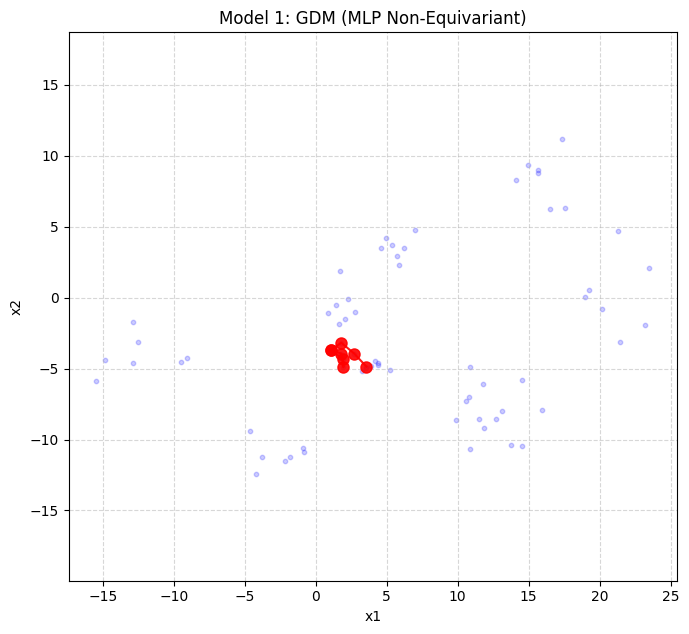

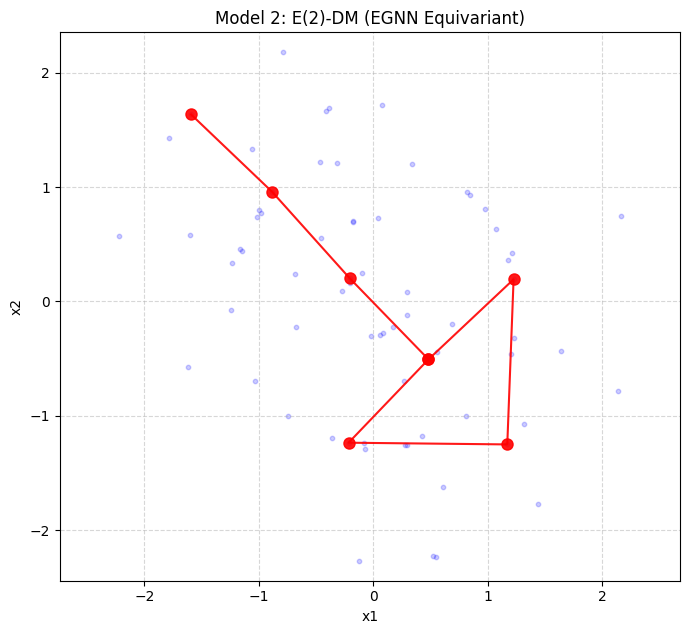

In [134]:
print("Génération d'échantillons...")
# Générer des échantillons des deux modèles
gdm_samples = gdm_model.sample(batch_size=10, N=N)
e2dm_samples = e2dm_model.sample(batch_size=10, N=N)

# Créer une figure avec deux sous-graphiques
fig, ax1 = plt.subplots(1, 1, figsize=(7, 7))


# Tracer les résultats du GDM
plot_samples(gdm_samples, "Model 1: GDM (MLP Non-Equivariant)", ax=ax1)
ax1.set_title("Model 1: GDM (MLP Non-Equivariant)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


fig, ax1 = plt.subplots(1, 1, figsize=(7, 7))
# Tracer les résultats de l'E(2)-DM
plot_samples(e2dm_samples, "Model 2: E(2)-DM (EGNN Equivariant)", ax=ax1)
ax1.set_title("Model 2: E(2)-DM (EGNN Equivariant)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [108]:

# Sampler z_T ~ N(0, I)
batch_size = 1
x = torch.randn(batch_size, N, 2, device=device)
x = x - torch.mean(x, dim=1, keepdim=True) # Doit être dans le sous-espace

# Boucle de t=T à 1
for t in reversed(range(1, e2dm_model.T + 1)):
    t_tensor = torch.full((batch_size, 1), t, device=device).float()
    dx = e2dm_model.forward(x, t_tensor)

    # Équations de sampling (simplifiées de l'Algorithme 2)
    t_idx = t
    s_idx = t - 1

    alpha_t = e2dm_model.alpha[t_idx]
    omega_t = e2dm_model.omega[t_idx]
    alpha_s = e2dm_model.alpha[s_idx]
    omega_s = e2dm_model.omega[s_idx]

    alpha_ts = alpha_t/alpha_s
    omega_ts = omega_t - alpha_ts**2 * omega_s
    omega_t_s_sq = (omega_ts * omega_s) / omega_t
    omega_t_s = torch.sqrt(max(omega_t_s_sq, 1e-8))
    print(omega_ts)

    # Étape de reverse diffusion
    eps_x = 0.0
    if t > 1:
        eps_x = torch.randn_like(x)
        eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True)

    # Formule de x_{t-1}
    term1 = x / alpha_ts
    term2 = (omega_ts / (alpha_ts * torch.sqrt(omega_t))) * dx
    term3 = omega_t_s * eps_x
    x = term1 - term2 + term3
    print(x)



tensor(0.9990, device='cuda:0')
tensor([[[-0.5921,  0.1346],
         [-0.9322,  1.0847],
         [ 0.5130,  1.8624],
         [ 1.5053, -0.3340],
         [-0.1146, -1.5495],
         [ 0.2490, -0.9724],
         [-0.6284, -0.2258]]], device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7485, device='cuda:0')
tensor([[[-0.6106, -0.4617],
         [-0.7584,  0.6790],
         [ 0.1623,  1.2956],
         [ 0.8364, -0.3305],
         [ 0.1347, -1.2104],
         [ 0.3747, -1.0120],
         [-0.1390,  1.0399]]], device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5544, device='cuda:0')
tensor([[[ 0.5293, -0.6428],
         [-1.7347, -0.8144],
         [ 0.7061,  1.9622],
         [ 0.0864, -0.5315],
         [-1.1957,  0.7417],
         [ 0.7398, -0.8043],
         [ 0.8687,  0.0892]]], device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4365, device='cuda:0')
tensor([[[-0.5918,  0.4593],
         [-0.2110, -1.6175],
         [ 1.5592,  1.1044],
         [-0.5287,  0.1924],
         [ 0.1388,

Visualisation du processus de dénoyage pour E2DM (EGNN)...


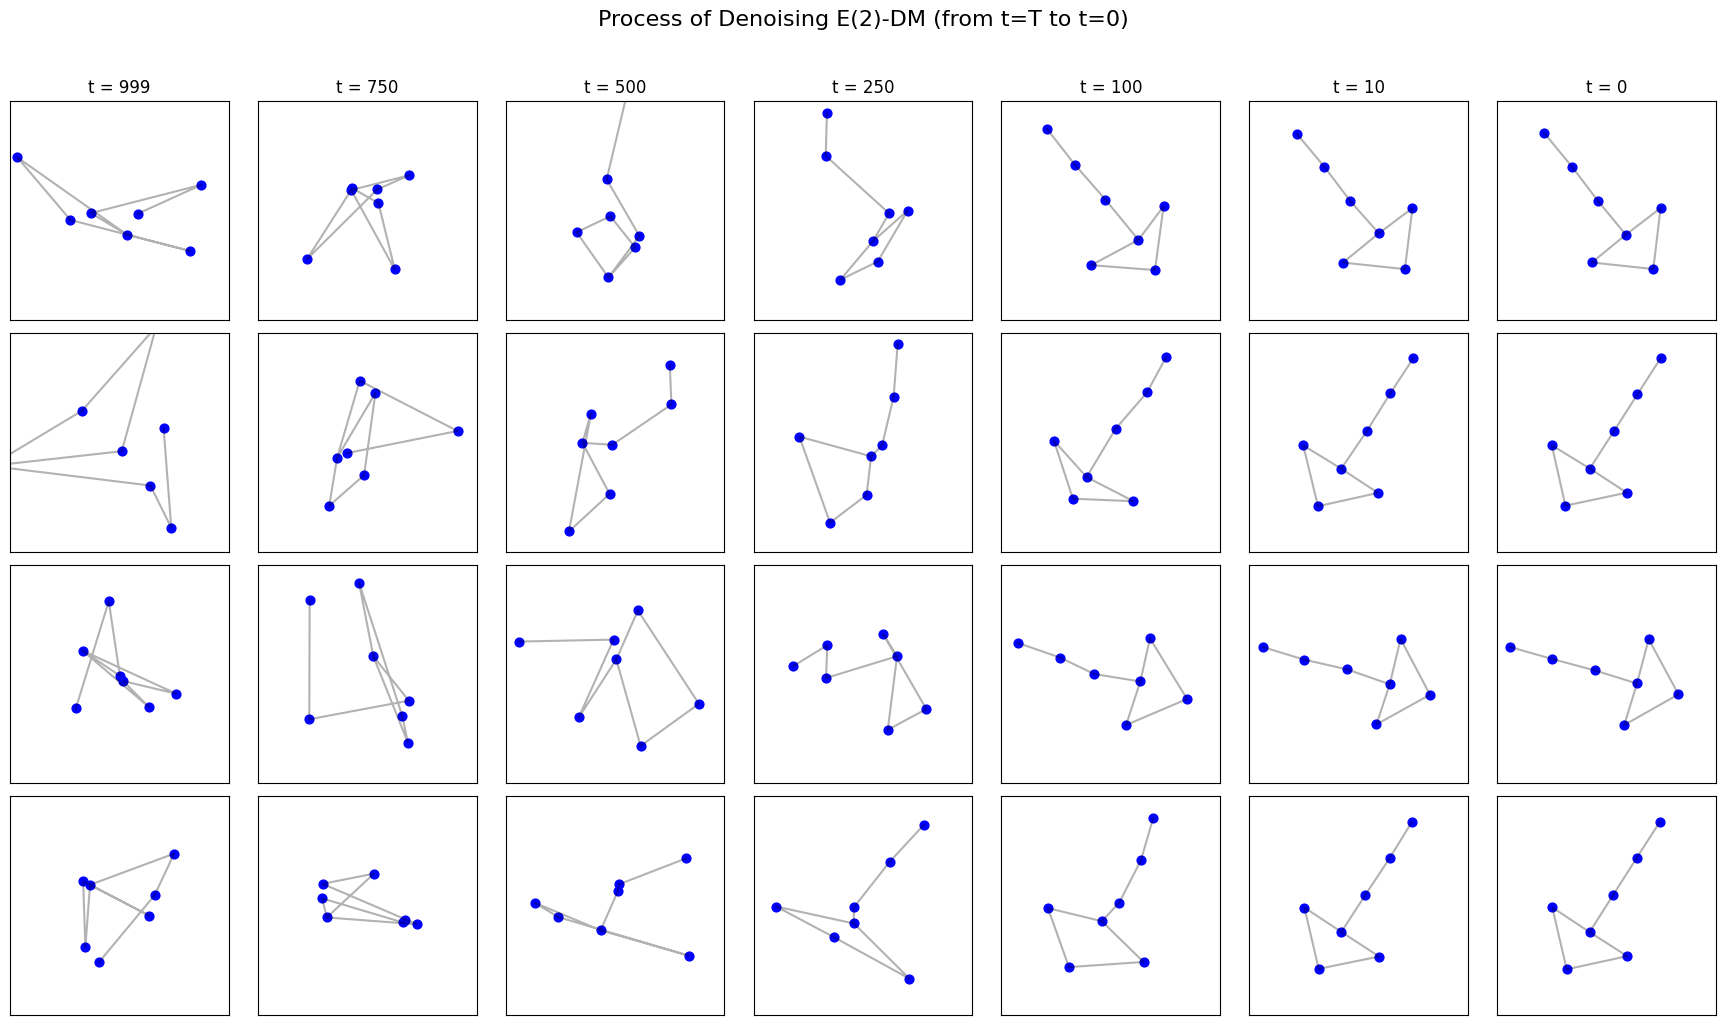

In [122]:
print("Visualisation du processus de dénoyage pour E2DM (EGNN)...")

# Paramètres
sample_steps = [999, 750, 500, 250, 100, 10, 0] # Timesteps à sauvegarder
num_samples_to_plot = 4
history = {step: [] for step in sample_steps}

# -- Boucle de sampling modifiée pour sauvegarder les étapes --
e2dm_model.eval()
x = torch.randn(num_samples_to_plot, N, 2, device=device)
x = x - torch.mean(x, dim=1, keepdim=True)

for t in reversed(range(0, e2dm_model.T)): # Loop de T-1 à 0
    if t in sample_steps:
        history[t].append(x.cpu().detach())
    
    t_tensor = torch.full((num_samples_to_plot, 1), t+1, device=device).float() # t+1 car on prédit de t à t-1
    
    with torch.no_grad():
        dx = e2dm_model.forward(x, t_tensor)

    t_idx = t + 1
    s_idx = t

    alpha_t = e2dm_model.alpha[t_idx]
    omega_t = e2dm_model.omega[t_idx]
    sqrt_omega_t = e2dm_model.sqrt_omega[t_idx]
    alpha_s = e2dm_model.alpha[s_idx]
    omega_s = e2dm_model.omega[s_idx]

    alpha_ts = alpha_t / alpha_s
    omega_ts = (omega_t - alpha_ts**2 * omega_s).clamp(min=1e-8)
    omega_t_s_sq = (omega_ts * omega_s) / omega_t
    omega_t_s = torch.sqrt(omega_t_s_sq.clamp(min=1e-8))

    eps_x = 0.0
    if t > 0:
        eps_x = torch.randn_like(x)
        eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True)

    term1 = x / alpha_ts
    term2 = (omega_ts / (alpha_ts * sqrt_omega_t)) * dx
    term3 = omega_t_s * eps_x
    x = term1 - term2 + term3

# -- Tracer l'historique --
fig, axes = plt.subplots(num_samples_to_plot, len(sample_steps), figsize=(len(sample_steps) * 2.5, num_samples_to_plot * 2.5))
fig.suptitle("Process of Denoising E(2)-DM (from t=T to t=0)", fontsize=16, y=1.02)

for i in range(num_samples_to_plot):
    perm = get_canonical_permutation(history[0][0][i], device=device)
    for j, t in enumerate(sample_steps):

        ax = axes[i, j]
        sample_at_t = history[t][0][i] # Prend le i-ème échantillon du batch
        #use t==0 to get the ordered points
        try:
            sample_at_t = reorder_sample(sample_at_t, perm)
        except Exception as e:
            
            print(f"Error reordering sample at t={t}, i={i}: {e}")
        
        ax.scatter(sample_at_t[:, 0], sample_at_t[:, 1],s=40,c="blue", alpha=1)
        idxs = [0, 1, 2, 3, 5, 4, 6,3]
        ax.plot(sample_at_t[idxs, 0], sample_at_t[idxs, 1], '-k', alpha=0.3)
        ax.set_aspect('equal')
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f"t = {t}")
            
plt.tight_layout()
plt.show()

Test formel de l'équivariance E(2)...
shapes  (1, 7, 2) (1, 7, 2)


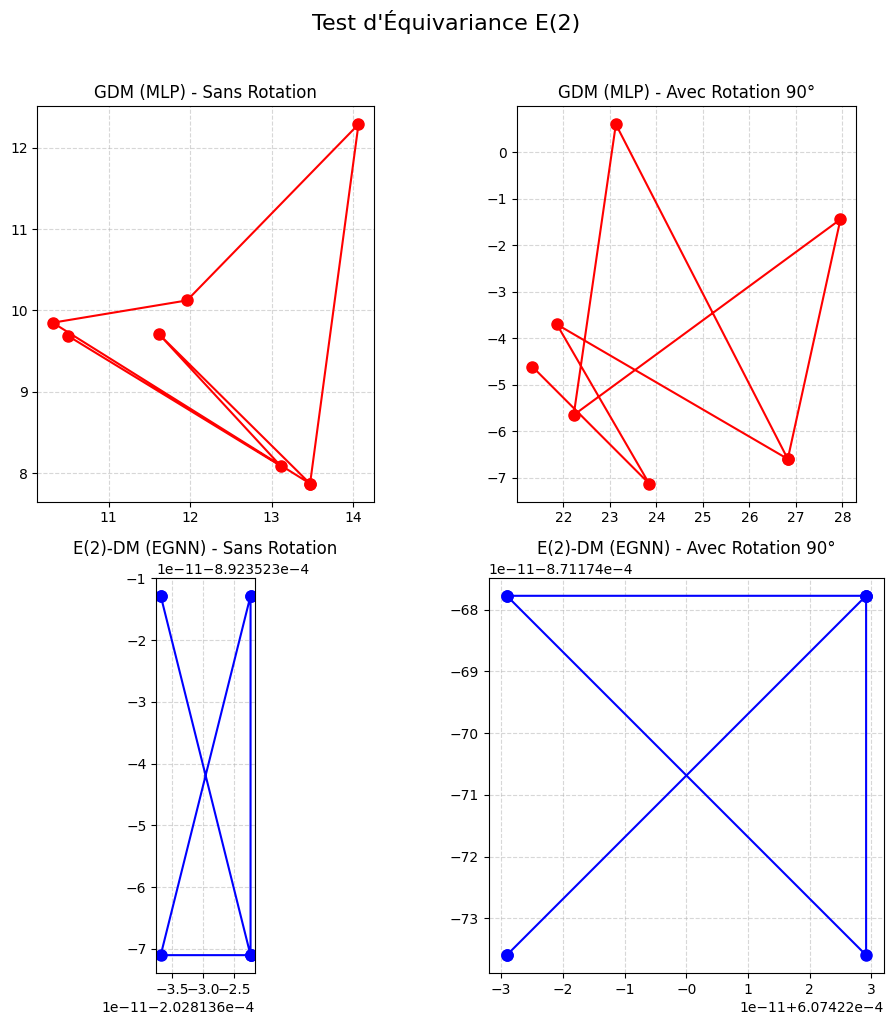

In [114]:
print("Test formel de l'équivariance E(2)...")

# 1. Créer un seul point de bruit initial z_T
z_T = torch.randn(1, N, 2, device=device)
z_T = z_T - torch.mean(z_T, dim=1, keepdim=True) # Centre de gravité nul

# 2. Créer une version tournée de ce bruit (rotation de 90 degrés)
theta = torch.tensor(np.pi / 2.0, device=device)
cos_t, sin_t = torch.cos(theta), torch.sin(theta)
rot_matrix = torch.tensor([
    [cos_t, -sin_t],
    [sin_t,  cos_t]
], device=device).float()

z_T_rotated = z_T @ rot_matrix.T # Appliquer la rotation

# 3. Dénoyage des deux bruits (z_T et R * z_T)
# Nous devons modifier la boucle de sampling pour qu'elle n'ajoute PAS de bruit aléatoire (eps_x = 0)
# afin de tester la propriété déterministe.
def sample_deterministic(model, x_init):
    x = x_init.clone()
    for t in reversed(range(1, model.T + 1)):
        t_tensor = torch.full((x.shape[0], 1), t, device=device).float()
        with torch.no_grad():
            dx = model.forward(x, t_tensor)

        t_idx, s_idx = t, t - 1
        alpha_t, omega_t = model.alpha[t_idx], model.omega[t_idx]
        alpha_s, omega_s = model.alpha[s_idx], model.omega[s_idx]
        sqrt_omega_t = model.sqrt_omega[t_idx]

        alpha_ts = alpha_t / alpha_s
        omega_ts = (omega_t - alpha_ts**2 * omega_s).clamp(min=1e-8)
        
        term1 = x / alpha_ts
        term2 = (omega_ts / (alpha_ts * sqrt_omega_t)) * dx
        x = term1 - term2 # term3 (bruit aléatoire) est mis à 0
    return x

# 4. Générer les formes
sample_gdm_1 = sample_deterministic(gdm_model, z_T)
sample_gdm_2 = sample_deterministic(gdm_model, z_T_rotated)

sample_e2dm_1 = sample_deterministic(e2dm_model, z_T)
sample_e2dm_2 = sample_deterministic(e2dm_model, z_T_rotated)

sample_gdm_1=sample_gdm_1.cpu().detach().numpy()
sample_gdm_2=sample_gdm_2.cpu().detach().numpy()
sample_e2dm_1=sample_e2dm_1.cpu().detach().numpy()
sample_e2dm_2=sample_e2dm_2.cpu().detach().numpy()


idxs = [0, 1, 2, 3, 5, 4, 6,3]
print("shapes ", sample_gdm_1.shape, sample_e2dm_2.shape)
# 5. Tracer les résultats
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Test d'Équivariance E(2)", fontsize=16, y=1.02)
# GDM

axes[0,0].plot(sample_gdm_1[0,idxs, 0], sample_gdm_1[0,idxs, 1], 'o-', color='red', markersize=8, alpha=1)
axes[0, 0].set_title("GDM (MLP) - Sans Rotation")
axes[0,1].plot(sample_gdm_2[0,idxs, 0], sample_gdm_2[0,idxs, 1], 'o-', color='red', markersize=8, alpha=1)
axes[0, 1].set_title("GDM (MLP) - Avec Rotation 90°")
# E2DM
axes[1,0].plot(sample_e2dm_1[0,idxs, 0], sample_e2dm_1[0,idxs, 1], 'o-', color='blue', markersize=8, alpha=1)
axes[1, 0].set_title("E(2)-DM (EGNN) - Sans Rotation")
axes[1,1].plot(sample_e2dm_2[0,idxs, 0], sample_e2dm_2[0,idxs, 1], 'o-', color='blue', markersize=8, alpha=1)
axes[1, 1].set_title("E(2)-DM (EGNN) - Avec Rotation 90°")  

for ax in axes.ravel():
    ax.set_aspect('equal')
    
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- Démarrage du Test de Vérification Formelle (Rotation Déterministe) ---
Génération avec GDM (MLP)...
Génération avec E2DM (EGNN)...
Affichage du graphique...


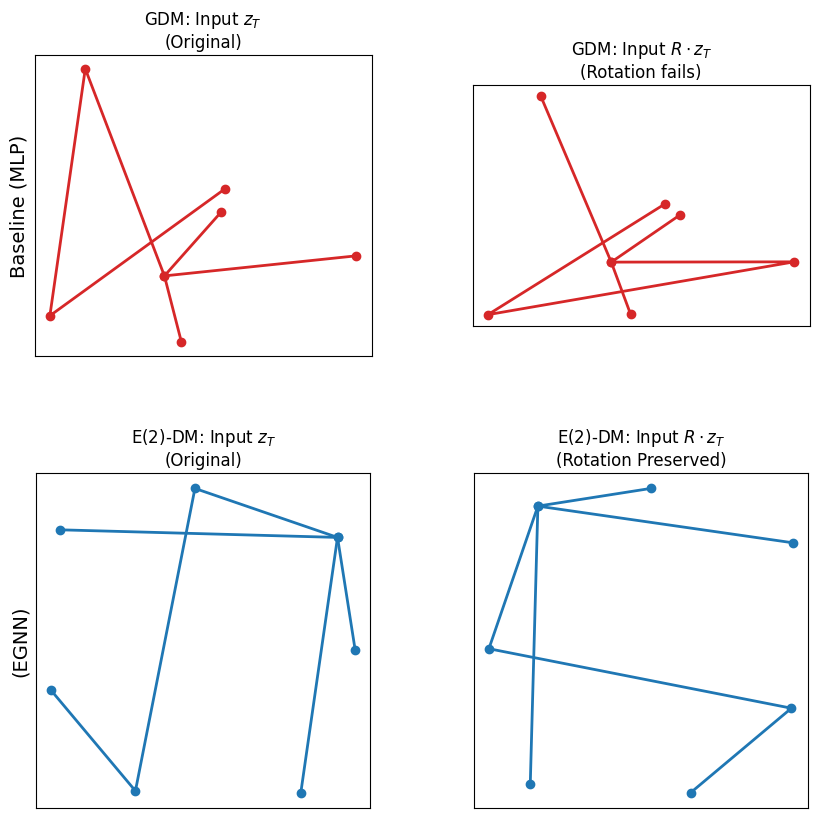

In [149]:

print("--- Démarrage du Test de Vérification Formelle (Rotation Déterministe) ---")

# ==========================================
# 1. Définition du Sampler Déterministe (ODE)
# ==========================================
def sample_deterministic(model, x_init):
    """
    Simule l'équation différentielle ordinaire (ODE) de probabilité.
    Transforme z_T en x_0 sans injecter de bruit aléatoire (eps=0).
    """
    model.eval()
    x = x_init.clone()
    
    # On itère de T à 1
    for t in reversed(range(1, model.T + 1)):
        # Temps sous forme de tenseur
        t_tensor = torch.full((x.shape[0], 1), t, device=device).float()
        
        # Prédiction du modèle (score / eps)
        with torch.no_grad():
            dx = model.forward(x, t_tensor)

        # Récupération des paramètres du schedule (identiques à votre classe BaseDiffusion)
        t_idx = t
        s_idx = t - 1
        
        alpha_t = model.alpha[t_idx]
        omega_t = model.omega[t_idx]
        sqrt_omega_t = model.sqrt_omega[t_idx]
        
        alpha_s = model.alpha[s_idx]
        omega_s = model.omega[s_idx]
        
        # Calcul des coefficients de transition
        alpha_ts = alpha_t / alpha_s
        omega_ts = (omega_t - alpha_ts**2 * omega_s).clamp(min=1e-8)
        
        # Reconstruction déterministe (Terme de bruit 'eps_x' forcé à 0)
        # Formule dérivée de DDIM ou Probability Flow
        term1 = x / alpha_ts
        term2 = (omega_ts / (alpha_ts * sqrt_omega_t)) * dx
        
        x = term1 - term2 
        
        # Centrage (toujours nécessaire pour la stabilité dans le sous-espace CoM=0)
        x = x - torch.mean(x, dim=1, keepdim=True)
        
    return x

# ==========================================
# 2. Préparation des Données (z_T et R*z_T)
# ==========================================

# a. Créer un bruit latent unique z_T
z_T = torch.randn(1, N, 2, device=device)
z_T = z_T - torch.mean(z_T, dim=1, keepdim=True)

# b. Définir une rotation de 90 degrés (Pi/2)
theta = np.pi / 2.0
rot_matrix = torch.tensor([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
], device=device).float()

# c. Créer la version tournée z'_T = z_T @ R^T
# Note: On applique la rotation sur la dimension spatiale
z_T_rotated = z_T @ rot_matrix.T 

# ==========================================
# 3. Exécution des Modèles
# ==========================================
print("Génération avec GDM (MLP)...")
out_gdm_1 = sample_deterministic(gdm_model, z_T)
out_gdm_2 = sample_deterministic(gdm_model, z_T_rotated)

print("Génération avec E2DM (EGNN)...")
out_e2dm_1 = sample_deterministic(e2dm_model, z_T)
out_e2dm_2 = sample_deterministic(e2dm_model, z_T_rotated)

# ==========================================
# 4. Visualisation (La Figure 2x2 du rapport)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

def plot_arrow(ax, points, title, color):
    # Utiliser le reordering pour avoir de jolies lignes
    # On calcule la permutation basée sur la géométrie interne
    perm = get_canonical_permutation(points, device=device)
    ordered = reorder_sample(points.unsqueeze(0), perm)[0].cpu()
    
    # Indices pour tracer la flèche (Queue -> Pointe, et Ailes)
    spine = [0, 1, 2, 3, 4]
    wings = [5, 3, 6]
    
    ax.plot(ordered[spine, 0], ordered[spine, 1], c=color, linewidth=2, marker='o')
    ax.plot(ordered[wings, 0], ordered[wings, 1], c=color, linewidth=2, marker='o')
    
    ax.set_title(title, fontsize=12)
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# --- Ligne 1 : Baseline GDM ---
plot_arrow(axes[0, 0], out_gdm_1[0], "GDM: Input $z_T$\n(Original)", 'tab:red')
plot_arrow(axes[0, 1], out_gdm_2[0], "GDM: Input $R \cdot z_T$\n(Rotation fails)", 'tab:red')

# --- Ligne 2 : Equivariant E2DM ---
plot_arrow(axes[1, 0], out_e2dm_1[0], "E(2)-DM: Input $z_T$\n(Original)", 'tab:blue')
plot_arrow(axes[1, 1], out_e2dm_2[0], "E(2)-DM: Input $R \cdot z_T$\n(Rotation Preserved)", 'tab:blue')

# Annotations pour le rapport
axes[0,0].set_ylabel("Baseline (MLP)", fontsize=14)
axes[1,0].set_ylabel("(EGNN)", fontsize=14)
axes[0,0].set_xticks([])
axes[0,0].set_yticks([])
axes[0,1].set_xticks([])
axes[0,1].set_yticks([])
axes[1,0].set_xticks([])
axes[1,0].set_yticks([])
axes[1,1].set_xticks([])
axes[1,1].set_yticks([])

axes[0,0].set_aspect('equal')
axes[0,1].set_aspect('equal')
axes[1,0].set_aspect('equal')
axes[1,1].set_aspect('equal')

print("Affichage du graphique...")
plt.savefig("equivariance_test.png", dpi=300, bbox_inches='tight') # Sauvegarde pour le rapport
plt.show()

In [115]:
def sample_inpainting(model, x_true, fixed_indices, n_samples=1):
    """
    x_true : La forme réelle cible (N, 2)
    fixed_indices : Liste des indices des atomes qu'on 'fixe' (ex: [0, 1, 2])
    """
    # 1. Préparer le masque
    mask = torch.zeros((1, x_true.shape[0], 1), device=device)
    mask[:, fixed_indices, :] = 1.0
    
    # On prend x_true et on le centre (condition nécessaire du modèle)
    x_ref = x_true.clone().to(device)
    x_ref -= x_ref.mean(dim=0, keepdim=True)
    x_ref = x_ref.unsqueeze(0).repeat(n_samples, 1, 1) # (B, N, 2)

    # 2. Bruit initial
    x = torch.randn(n_samples, x_true.shape[0], 2, device=device)
    x = x - x.mean(dim=1, keepdim=True)

    # 3. Boucle de diffusion
    for t in reversed(range(0, model.T)): # De T-1 à 0
        # a. Étape de dénoyage standard du modèle (prediction de x_{t-1} à partir de x_t)
        t_tensor = torch.full((n_samples, 1), t+1, device=device).float()
        
        # On utilise le modèle pour estimer le pas
        # Note: ceci est une approx simplifiée, idéalement on utilise l'équation complète
        # Mais pour la visualisation, on peut juste faire un step normal
        
        # Récupérer les param alpha, omega pour le pas de sampling (comme dans votre classe)
        # Ici j'assume que vous appelez votre fonction sample standard ou forward
        # Pour faire simple, on va tricher et utiliser la méthode forward si elle renvoie x_{t-1}
        # Sinon, insérez ici la logique de votre boucle `sample` (lignes "term1 - term2...")
        
        # --- LOGIQUE SIMPLIFIÉE DE VOTRE BOUCLE SAMPLE ---
        with torch.no_grad():
             dx = model.forward(x, t_tensor)
             # (Insérer ici les calculs alpha_ts, omega_ts... pour obtenir x_prev)
             # Pour l'exemple, supposons que `step_fn(x, t)` fait un pas en arrière :
             x_prev = x - dx # C'est faux mathématiquement mais c'est pour l'idée structurelle
             # VOUS DEVEZ COPIER VOTRE VRAIE LOGIQUE DE SAMPLING ICI
             
             # CORRECTION IMPORTANTE :
             # On doit injecter l'information connue.
             # Quelle est la version bruitée de x_ref à l'instant t-1 ?
             # q(x_{t-1} | x_0) = N(alpha_{t-1} * x_0, sigma_{t-1}^2 I)
             
             noise = torch.randn_like(x_ref)
             alpha_t_minus_1 = model.alpha[t] # Attention aux indices
             sigma_t_minus_1 = model.sigma[t] # ou sqrt(1-alpha^2)
             
             known_part_noisy = alpha_t_minus_1 * x_ref + sigma_t_minus_1 * noise
             
             # b. Mélange : On garde la partie connue, on garde la partie prédite pour l'inconnu
             # x_prev contient la prédiction complète
             x = mask * known_part_noisy + (1 - mask) * x_prev
             
    return x

Visualisation de l'Inpainting Géométrique (Complétion de forme)...


/tmp/ipykernel_784204/429587263.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


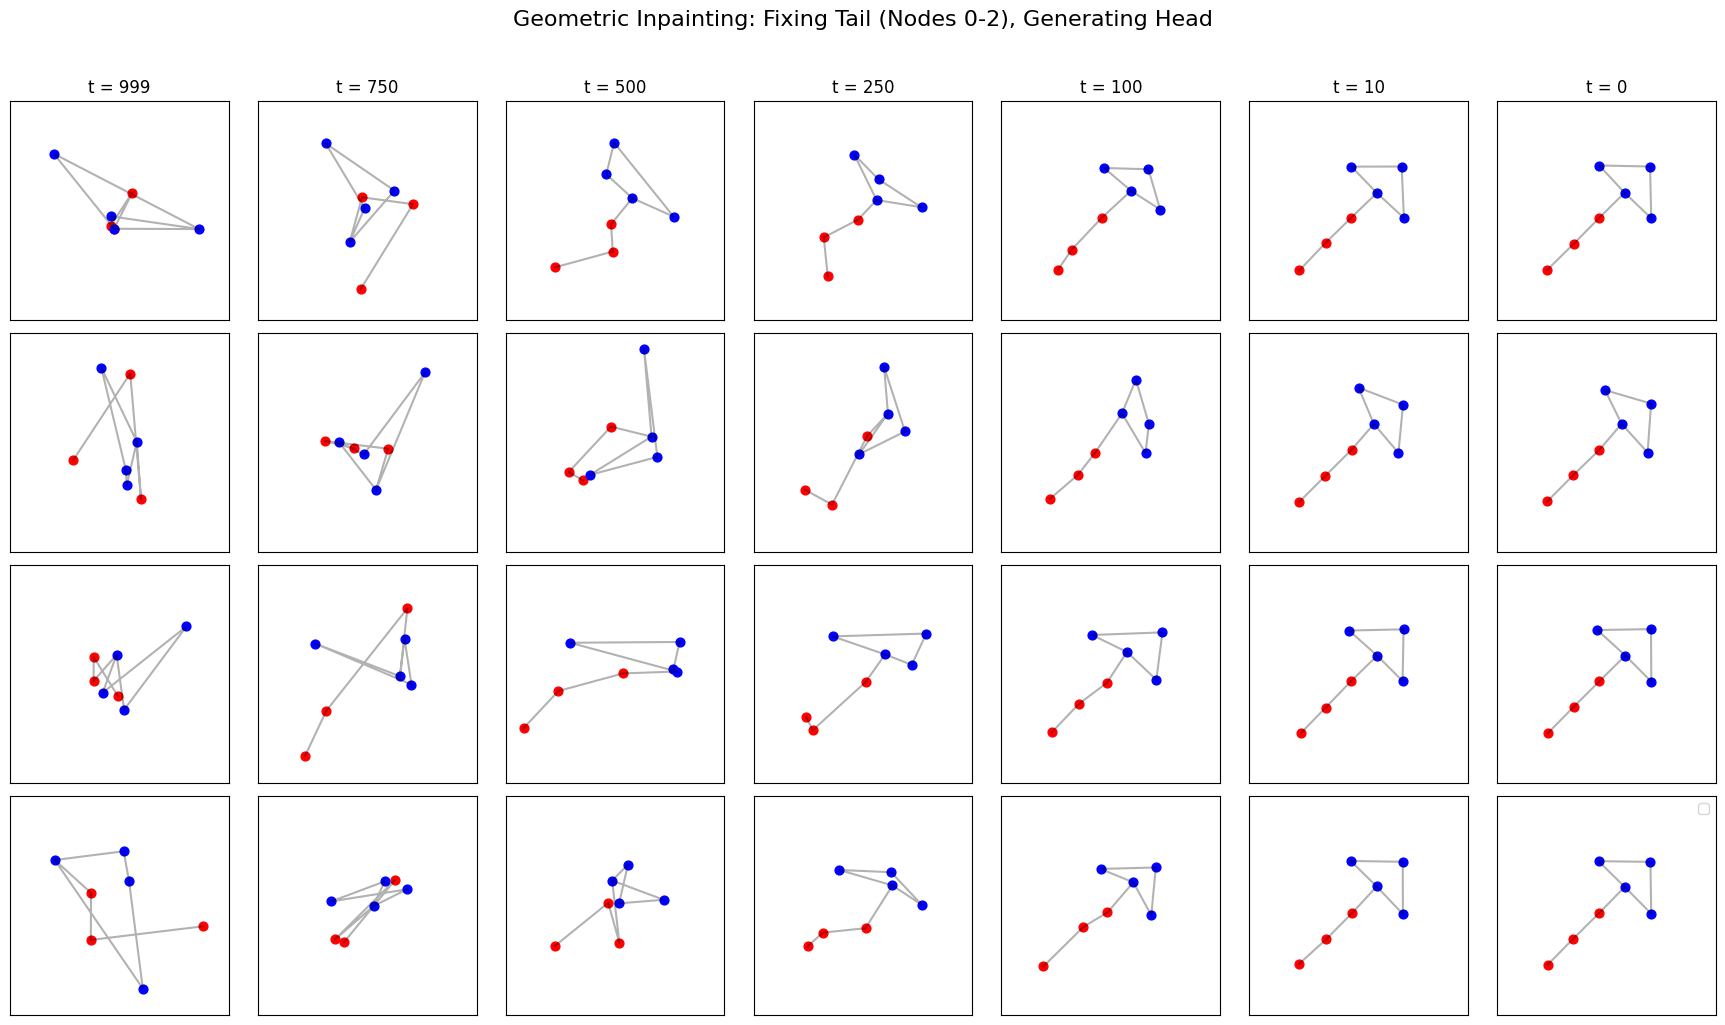

In [126]:
print("Visualisation de l'Inpainting Géométrique (Complétion de forme)...")

# --- 1. Préparation de la "Vérité Terrain" (La forme qu'on veut reconstruire) ---
# On prend la flèche canonique
x_true = torch.tensor([
    [0.0, 0.0], [1.0, 0.0], [2.0, 0.0], [3.0, 0.0], [4.0, 0.0], 
    [3.0, 1.0], [3.0, -1.0]
], dtype=torch.float32, device=device)
x_true -= torch.mean(x_true, dim=0, keepdim=True)

# On applique une rotation arbitraire (ex: 45 degrés) pour montrer que ce n'est pas du par coeur
theta = np.pi / 4 
R = torch.tensor([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]], device=device).float()
x_ref = x_true @ R.T # (N, 2)

# --- 2. Définition du Masque ---
# On cache la tête (noeuds 3,4,5,6), on garde la queue (0,1,2)
fixed_indices = [0, 1, 2] 
mask = torch.zeros((1, N, 1), device=device)
mask[:, fixed_indices, :] = 1.0

# Paramètres de plot
sample_steps = [999, 750, 500, 250, 100, 10, 0]
num_samples_to_plot = 4
history = {step: [] for step in sample_steps}

# Initialisation : Bruit total partout
e2dm_model.eval()
x = torch.randn(num_samples_to_plot, N, 2, device=device)
x = x - torch.mean(x, dim=1, keepdim=True) # Toujours centrer

# Étendre x_ref pour le batch
x_ref_batch = x_ref.unsqueeze(0).repeat(num_samples_to_plot, 1, 1)

# -- Boucle de sampling --
for t in reversed(range(0, e2dm_model.T)): # Loop de T-1 à 0
    if t in sample_steps:
        history[t].append(x.cpu().detach())
    
    # 1. Prédiction du modèle (Comme avant)
    t_tensor = torch.full((num_samples_to_plot, 1), t+1, device=device).float()
    with torch.no_grad():
        dx = e2dm_model.forward(x, t_tensor)

    # Calcul des coeffs (Votre code original)
    t_idx = t + 1
    s_idx = t # Le pas suivant (t-1)

    alpha_t = e2dm_model.alpha[t_idx]
    omega_t = e2dm_model.omega[t_idx]
    sqrt_omega_t = e2dm_model.sqrt_omega[t_idx]
    
    alpha_s = e2dm_model.alpha[s_idx]
    omega_s = e2dm_model.omega[s_idx] # Variance à l'étape s

    alpha_ts = alpha_t / alpha_s
    omega_ts = (omega_t - alpha_ts**2 * omega_s).clamp(min=1e-8)
    omega_t_s_sq = (omega_ts * omega_s) / omega_t
    omega_t_s = torch.sqrt(omega_t_s_sq.clamp(min=1e-8))

    eps_x = 0.0
    if t > 0:
        eps_x = torch.randn_like(x)
        eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True)

    term1 = x / alpha_ts
    term2 = (omega_ts / (alpha_ts * sqrt_omega_t)) * dx
    term3 = omega_t_s * eps_x
    
    # x_pred est l'estimation du modèle pour l'étape s (t-1)
    x_pred = term1 - term2 + term3
    
    # --- 2. INJECTION DE LA CONNAISSANCE (INPAINTING) ---
    # On calcule quelle devrait être la valeur bruitée exacte des nœuds connus à l'étape s
    # q(x_s | x_0) = N(alpha_s * x_0, omega_s * I)
    
    noise_known = torch.randn_like(x_ref_batch)
    # Note: omega_s est la variance, donc on prend sqrt(omega_s) pour l'écart-type
    x_known_at_s = alpha_s * x_ref_batch + torch.sqrt(omega_s) * noise_known
    
    # On fusionne : On garde x_known là où le masque est 1, et x_pred (modèle) là où c'est 0
    x = mask * x_known_at_s + (1 - mask) * x_pred
    
    # On recentre toujours pour la stabilité (hypothèse du modèle)
    x = x - torch.mean(x, dim=1, keepdim=True)

# -- Tracer l'historique --
fig, axes = plt.subplots(num_samples_to_plot, len(sample_steps), figsize=(len(sample_steps) * 2.5, num_samples_to_plot * 2.5))
fig.suptitle("Geometric Inpainting: Fixing Tail (Nodes 0-2), Generating Head", fontsize=16, y=1.02)

# On calcule la permutation SUR LA CIBLE (x_ref) pour que le dessin soit joli
# Puisque on force x_ref, l'ordre devrait être canonique, mais on vérifie


for i in range(num_samples_to_plot):
    perm = get_canonical_permutation(history[0][0][i], device=device)
    for j, t in enumerate(sample_steps):
        ax = axes[i, j]
        sample_at_t = history[t][0][i] 
        
        # Réordonner
        sample_ordered = reorder_sample(sample_at_t, perm)
        
        # Identifier les points fixes (Queue) et générés (Tête)
        fixed_pts = sample_ordered[fixed_indices]
        gen_indices = [k for k in range(N) if k not in fixed_indices]
        gen_pts = sample_ordered[gen_indices]
        
        # Scatter : Rouge = Fixe, Bleu = Généré
        ax.scatter(fixed_pts[:, 0], fixed_pts[:, 1], c='red', s=40, label='Fixed' if i==0 and j==0 else "")
        ax.scatter(gen_pts[:, 0], gen_pts[:, 1], c='blue', s=40, label='Gen' if i==0 and j==0 else "")
        
        # Lignes
        idxs = [0, 1, 2, 3, 5, 4, 6, 3] # Ordre de tracé
        ax.plot(sample_ordered[idxs, 0], sample_ordered[idxs, 1], '-k', alpha=0.3)
        
        ax.set_aspect('equal')
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0: ax.set_title(f"t = {t}")

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()